In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_token = user_secrets.get_secret("pfn_key")

# secret_token = "tabpfn_sk_BRazYGiNBKYBWNHuuOmOJUvMiqzHsLQLlPrRQMsBQ8Q"

RUN_LOCAL_MODEL = False
USE_PFN_TOKEN   = True

if RUN_LOCAL_MODEL:
    print("Loading tabpfn_local... ")
    os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1"
    try:
        from tabpfn import TabPFNClassifier
    except:
        !uv pip install tabpfn
        from tabpfn import TabPFNClassifier
    ## -----------------------------------------------------
    # if USE_PFN_TOKEN: # Option 1: Use secret token key
    #     os.environ["TABPFN_TOKEN"] = secret_token
    # else: # Option 2: Access to direct model
    #     os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1"
    print("Complete!")
else:
    print("Connecting tabpfn_client... ", end='')
    try:
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token
    except:
        !uv pip install tabpfn-client
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token

    tabpfn_client.set_access_token(secret_token)
    print("Complete!")

# secret_token

Connecting tabpfn_client... Using Python 3.12.13 environment at: /usr
Resolved 48 packages in 899ms
⠙ Preparing packages... (0/10)
⠙ Preparing packages... (0/10)
⠙ Preparing packages... (0/10)
⠙ Preparing packages... (0/10)
backoff              ------------------------------ 14.79 KiB/14.79 KiB
⠙ Preparing packages... (0/10)
backoff              ------------------------------ 14.79 KiB/14.79 KiB
⠙ Preparing packages... (0/10)
backoff              ------------------------------ 14.79 KiB/14.79 KiB
⠙ Preparing packages... (0/10)
backoff              ------------------------------ 14.79 KiB/14.79 KiB
pydantic-settings    ------------------------------     0 B/60.27 KiB
⠙ Preparing packages... (0/10)
backoff              ------------------------------ 14.79 KiB/14.79 KiB
pydantic-settings    ------------------------------ 16.00 KiB/60.27 KiB
⠙ Preparing packages... (0/10)
backoff              ------------------------------ 14.79 KiB/14.79 KiB
pydantic-settings    --------------------------

In [3]:
## -- Data Manipulation -- 
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, log_loss, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Original,Test
age,18,18,18
daily_screen_time_hours,1389,900,1349
social_media_hours,721,551,703
gaming_hours,401,401,401
work_study_hours,600,551,601
sleep_hours,451,451,451
notifications_per_day,231,231,231
app_opens_per_day,166,166,166
weekend_screen_time,1437,1096,1404
gender,3,3,3


In [8]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

In [9]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    wts = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return wts

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    cls = np.unique(y_true)
    wts = compute_class_weight('balanced', classes=cls, y=y_true)
    class_weights = dict(zip(cls, wts))
    return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [10]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [11]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [12]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [13]:
# train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

In [14]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [15]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS + ['LapNumber', 'RaceProgress']: # 'Position_Change'
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [16]:
# ## -- Arithmetic interaction --
# # u - g, g - r, r - i, i - z

# # ('u', 'g'),
# # ('g', 'r'),
# # ('i', 'z'),
# # ('g', 'i'),
# # ('r', 'z')

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']

#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_{band}_redshift_div_"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [17]:
# ## -- Cyclical extraction --
# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [18]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# INTER

In [19]:
# sleep(2); gc.collect()

In [20]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64:
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")

#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=n_unique.index[:10].tolist(),
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Original features merged: {len(orig_cols)}")

In [24]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')
#     orig[n]  = __[len(train)+len(test):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Features before:", len(FEATURES))

combined = pd.concat([train, test, orig])

## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
CATS_2 = []
for c in NUMS:
    n = f"cat_{c}"
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    CATS_2.append(n)
## ------------------------------------------------------------
## -- Factorize all CATS data --
# for c in CATS:
#     combined[c] = combined[c].factorize()[0]
    # combined[c] = combined[c].astype('category')
## ------------------------------------------------------------

FEATURES.extend(CATS_2)
print("Features after:", len(FEATURES))

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Features before: 12
Features after: 21
Label encoding complete!


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,7,342,163,82,248,312,102,77,154,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,-1,-1,-1,-1,43,292,-1,164,599,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,12,26,137,196,150,40,91,135,290,1.0


In [26]:
# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train, INDI_COLS = appy_nan_indicator(train)
# test, _  = appy_nan_indicator(test)
# orig, _  = appy_nan_indicator(orig)

# # ## -- Fill categorical --
# # train[CATS] = train[CATS].fillna('missing')
# # test[CATS]  = test[CATS].fillna('missing')
# # orig[CATS]  = orig[CATS].fillna('missing')

# print(INDI_COLS)
# train

In [27]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 21


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,7,342,163,82,248,312,102,77,154,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,-1,-1,-1,-1,43,292,-1,164,599,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,12,26,137,196,150,40,91,135,290,1.0


# ML TRAINING

In [28]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    cat_cols=None, use_orig=False):

    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test_df))
    fold_scores = []

    if 'group_kf' in model_name:
        print("Using GROUP splits --- ")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print("Using REGULAR splits --- ")
        splitter = kfold.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end="")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate orginal data --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean"], # mean, median, "count", "std", skew, nunique, max, min
                fill_nan=True,
            )

        te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)

        print(f"shape: {X_train.shape}")

        cat_idx = [[*X_train.columns].index(f) for f in cat_cols]
        print("cat_idx:", cat_idx)

        model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
        model.fit(X_train, y_train)

        ## -- Predictions --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]

        ## -- Split test: limit 200k
        part_1_preds = model.predict_proba(X_test[:150_000])
        part_2_preds = model.predict_proba(X_test[150_000:])
        test_preds += np.vstack((part_1_preds, part_2_preds))[:, 1] / kfold.n_splits

        ## -- Calculate fold scores --
        fold_score  = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        print(f"{CFG['YELLOW']}Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- Clean up memory --
        torch.cuda.empty_cache()

    # ## -- Average test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [29]:
# def Trainer_CV(
#     model_name, params, train_df, test_df, features, target, kfold,
#     multi_seeds=[42, 111, 0], cat_cols=None, use_orig=False):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features]
#     y = train_df[target]

#     num_cls = y.nunique()

#     oof_preds   = np.zeros((len(X), num_cls))
#     test_preds  = np.zeros((len(test_df), num_cls))
#     fold_scores = []
#     brier_scores = []

#     if 'group_kf' in model_name:
#         print("Using GROUP splits --- ")
#         strat_id = y.astype(str) + '__' + X['Year'].astype(str)
#         splitter = kfold.split(X, strat_id)
#     else:
#         print("Using REGULAR splits --- ")
#         splitter = kfold.split(X, y)

#     for idx, (train_idx, val_idx) in enumerate(splitter, 1):
#         print(f"\n***** FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end='')

#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         oof_seeds  = np.zeros((len(X_valid), num_cls))
#         test_seeds = np.zeros((len(X_test), num_cls))

#         ## -- Concatenate orginal data --
#         if use_orig:
#             X_train = pd.concat([X_train, orig[features]], ignore_index=True)
#             y_train = pd.concat([y_train, orig[target]], ignore_index=True)
#             # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="Training seeds"):
#             print(f"Training with seed -> {seed}")
#             params['random_state'] = seed

#             ## -- Shuffle X_train --
#             full_train = pd.concat([X_train, y_train], axis=1)
#             shuffled_full_train = full_train.sample(frac=1.0, random_state=seed)
#             X_train_1 = shuffled_full_train.iloc[:, :-1].copy()
#             y_train_1 = shuffled_full_train.iloc[:, -1].copy()
#             ## -----------------------------------------------------------------------------
#             print(f"X_train: {X_train.shape} *****")
    
#             cat_idx = [[*X_train_1.columns].index(f) for f in cat_cols]
#             print(cat_idx)
    
#             model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
#             model.fit(X_train, y_train)

#             oof_seeds  += model.predict_proba(X_valid)
            
#             ## -- Split test: limit 200k
#             part_1_preds = model.predict_proba(X_test[:150_000])
#             part_2_preds = model.predict_proba(X_test[150_000:])
#             test_seeds += np.vstack((part_1_preds, part_2_preds))

#             print(f"\tSeed ({seed}) score: {roc_auc_score(y_valid, model.predict_proba(X_valid)):.5f}")

#         ## -- Predict on val and test sets --
#         oof_preds[val_idx] = oof_seeds / len(multi_seeds)
#         test_preds += test_seeds / len(multi_seeds)
        
#         ## -- Calculate fold scores --
#         fold_score  = roc_auc_score(y_valid, oof_preds[val_idx])
#         brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#         fold_scores.append(fold_score)
#         brier_scores.append(brier_score)

#         print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#         ## -- Clean up memory --
#         torch.cuda.empty_cache()

#     ## -- Average test predictions --
#     test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(roc_auc_score(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'model': model,
#         'val_data': X_valid,
#     }

# print("⚙️ Trainer function ready ⚙️")

In [30]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
USE_CALIBATOR  = False

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,7,342,163,82,248,312,102,77,154,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,-1,-1,-1,-1,43,292,-1,164,599,1.0
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,12,26,137,196,150,40,91,135,290,1.0


In [31]:
# !rm -r /kaggle/working

### Balancing for Balanced Metrics

Setting `balance_probabilities=True` is a simple heuristic for imbalanced data when your evaluation metric weights each class equally regardless of its frequency (e.g. `balanced accuracy`, `balanced log loss`). It re-weights the output probabilities based on the class frequencies in the training data.


This is a simpler, non-optimized alternative to `eval_metric="balanced_accuracy"` with `tune_decision_thresholds=True`.


In [32]:
local_params = {
    "n_estimators": 2,
    "inference_config": {"SUBSAMPLE_SAMPLES": 100_000}, # Subsample at inference
    "ignore_pretraining_limits": True, # Ignore 100k limit
    "random_state": CFG['SEED'],
    # "model_path": "tabpfn-v3-classifier-v3_20260417_binary.ckpt",
    # ---------------------------------------------------------------------------
    "device": ["cuda:0", "cuda:1"], # 'auto'
    "fit_mode": "fit_with_cache",
    "eval_metric": "roc_auc",
    # 'tuning_config': {'tune_decision_thresholds': True}, # f1, accuracy
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, # loss, brier
    # ---------------------------------------------------------------------------
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

client_params = {
    ## -- thinking_mode limited to 200k train set --
    # 'thinking_mode': True,
    # 'thinking_effort': 'high',
    # 'thinking_metric': 'accuracy',
    # ---------------------------------------------------------------------------
    # 'n_estimators': 2, # 6
    # 'inference_config': {'SUBSAMPLE_SAMPLES': 100_000}, # Subsample at inference
    # 'ignore_pretraining_limits': True, # Ignore 100k limit
    'random_state': CFG['SEED'],
    # ---------------------------------------------------------------------------
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

n = "tabpfn" if RUN_LOCAL_MODEL else "tabpfn_client"

# for VALUE in [4, 6, 8]:
#     PARAMS['n_estimators'] = VALUE
#     n = f"{VERS}_{str(VALUE)}"
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=local_params if RUN_LOCAL_MODEL else client_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=CATS,
    # use_orig=True,
    # multi_seeds=MULTI_SEEDS,
)


===== Starting CV: tabpfn_client =====
Using REGULAR splits --- 

##### FOLD 1/5 | CPU: 4 | shape: (553095, 21)
cat_idx: [9, 10, 11]
00:10 Fitting... Done!
08:02 Predicting... Done!
08:11 Predicting... Done!
08:10 Predicting... Done!
Fold 1 AUC: 0.966182

##### FOLD 2/5 | CPU: 4 | shape: (553095, 21)
cat_idx: [9, 10, 11]
00:11 Fitting... Done!
23:18 Predicting... Done!
08:12 Predicting... Done!
08:09 Predicting... Done!
Fold 2 AUC: 0.967032

##### FOLD 3/5 | CPU: 4 | shape: (553095, 21)
cat_idx: [9, 10, 11]
00:10 Fitting... Done!
18:19 Predicting... Done!
08:06 Predicting... Done!
08:09 Predicting... Done!
Fold 3 AUC: 0.967209

##### FOLD 4/5 | CPU: 4 | shape: (553095, 21)
cat_idx: [9, 10, 11]
00:10 Fitting... Done!
08:06 Predicting... Done!
08:06 Predicting... Done!
08:12 Predicting... Done!
Fold 4 AUC: 0.967637

##### FOLD 5/5 | CPU: 4 | shape: (553096, 21)
cat_idx: [9, 10, 11]
00:10 Fitting... Done!
08:03 Predicting... Done!
08:12 Predicting... Done!
08:07 Predicting... Done!
Fold 

In [33]:
# ==================================================
# 5-FOLD CV: tabpfn | TE(CATS_2) | (165928, 21)
# ==================================================
#  • Fold 1 AUC: 0.964645
#  • Fold 2 AUC: 0.965345
#  • Fold 3 AUC: 0.964426
#  • Fold 4 AUC: 0.965879
#  • Fold 5 AUC: 0.965360
# -------------------------------------------------|
# OOF score: 0.965081
# AVG score: 0.965131 ± 0.000527
# -------------------------------------------------|
# 18.64 mins

# ==================================================
# 5-FOLD CV: tabpfn | TE_orig(mean) (165928, 24)
# ==================================================
#  • Fold 1 AUC: 0.957995
#  • Fold 2 AUC: 0.958732
#  • Fold 3 AUC: 0.957541
#  • Fold 4 AUC: 0.959752
#  • Fold 5 AUC: 0.957966
# -------------------------------------------------|
# OOF score: 0.958316
# AVG score: 0.958397 ± 0.000778
# -------------------------------------------------|
# 18.78 mins

# ==================================================
# 5-FOLD CV: tabpfn | (165928, 12)
# ==================================================
#  • Fold 1 AUC: 0.943320
#  • Fold 2 AUC: 0.943547
#  • Fold 3 AUC: 0.943334
#  • Fold 4 AUC: 0.946491
#  • Fold 5 AUC: 0.944984
# -------------------------------------------------|
# OOF score: 0.944268
# AVG score: 0.944335 ± 0.001243
# -------------------------------------------------|
# 18.25 mins

In [34]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_scores[k] = y

all_scores

# plt.figure(figsize=(16, 6))
# ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_scores)), all_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# # ax.set_ylim(0.95, 0.955)

# for i, s in enumerate(all_scores.values()):
#     ax.text(float(i), s+1e-4, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

{'tabpfn_client': np.float64(0.966928)}

tabpfn_client_966928 saved!


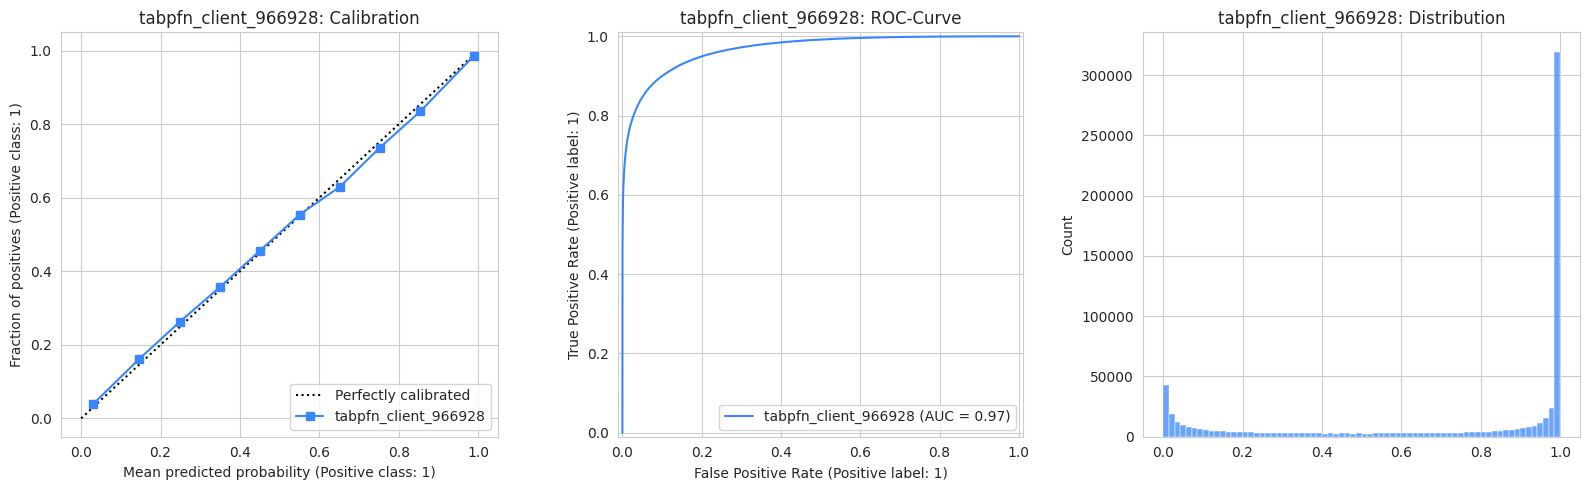

In [35]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [36]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

tabpfn_client_966928 saved! (296302,)


In [37]:
pd.DataFrame(model_results)

,tabpfn_client_966928
0,0.999867
1,0.969143
2,0.741177
3,0.998060
4,0.999589
...,...
296297,0.999987
296298,0.548007
296299,0.153853
296300,0.901644


In [38]:
# !rm -r /kaggle/working